In [1]:
%pip install -r requirements-offline.txt --quiet

/Users/utarn/projects/ml-metrology/.claude/worktrees/issue-29/.check-env/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


# Module M4 — เสียง → ตัวเลข → โมเดล (ESC-50: MFCC + random forest)

โมดูลนี้คือ **สะพานจากคอร์ส DS**: เสียงดิบฟังไม่รู้เรื่องและไม่ใช่ตาราง แต่พอแปลงเป็น
**ตัวเลขในตาราง** (MFCC features) ได้ เราก็ใช้วิธีเดิมที่คุ้นเคย — random forest ของ
sklearn — ได้ทันที ครึ่งหลังของโมดูล (spectrogram CNN) อยู่ที่
`day2/module4_esc50_cnn/` และใช้ **ข้อมูลเดียวกันนี้** เพื่อเทียบ accuracy กันตรง ๆ

- โมดูลนี้รัน **offline บน CPU** — ใช้ sklearn + librosa เท่านั้น (ไม่ต้องมี GPU)
- รันทั้งไฟล์ใช้เวลาราว **3–5 นาทีบน CPU** (ครั้งแรกจะช้ากว่านั้นถ้าต้องดาวน์โหลดข้อมูล)
- ข้อมูล ESC-50 **ไม่ได้แถมมากับ repo** (license ห้ามแจกต่อเชิงพาณิชย์) — เซลล์ถัดไปหาจากดิสก์ก่อน ถ้าไม่มีจะดาวน์โหลดให้ครั้งเดียว

**ที่มาและ license ของทุกอย่างที่โมดูลนี้ใช้**

| สิ่งที่ใช้ | ที่มา | license |
|---|---|---|
| ESC-50 — เสียงสิ่งแวดล้อม 2,000 คลิป (5 วินาที/คลิป, 50 class × 40 คลิป, แบ่ง 5 folds มาให้แล้ว) | [github.com/karoldvl/ESC-50](https://github.com/karoldvl/ESC-50) · [paper: Piczak, ACM MM 2015](http://karol.piczak.com/papers/Piczak2015-ESC-Dataset.pdf) | **CC BY-NC 3.0** ⚠️ **non-commercial** — ใช้ในห้องเรียนได้ แต่ **ห้ามแจกต่อเชิงพาณิชย์** (ดูหมายเหตุด้านล่าง) |
| librosa (โหลดเสียง + MFCC/spectrogram) | [github.com/librosa/librosa](https://github.com/librosa/librosa) | **ISC** |
| scikit-learn (random forest + metrics) | [github.com/scikit-learn/scikit-learn](https://github.com/scikit-learn/scikit-learn) | **BSD-3** |
| PyTorch (เฉพาะโมดูล CNN) | [github.com/pytorch/pytorch](https://github.com/pytorch/pytorch) | **BSD-3** |

> ⚠️ **หมายเหตุ license ESC-50 (CC BY-NC 3.0):** ใช้เพื่อการเรียนการสอนในห้องได้ฟรี
> แต่ **ห้ามนำไปแจกต่อ/ขาย/รวมลงสื่อที่แจกเชิงพาณิชย์** — repo นี้จึง **ไม่ใส่ไฟล์เสียง
> มาให้** ทุกคนต้องดาวน์โหลดเองครั้งเดียว (เซลล์ถัดไปจัดการให้) ถ้าวันหนึ่งต้องการ
> สื่อที่แจกต่อเชิงพาณิชย์ได้ ให้สลับไปใช้ **Speech Commands v2 (CC BY 4.0)**
> แทน — โครงสร้างโค้ดเปลี่ยนน้อยมาก

## 0. โน้ตช่วย — คำศัพท์ที่ใช้ในโมดูลนี้

| คำ | ความหมาย |
|---|---|
| **waveform** | คลื่นเสียงดิบ — ความดันอากาศที่จับมาเป็นตัวเลข วินาทีละหลายพันค่า (คลิป 5 วินาที @ 22,050 Hz = ~110,250 ตัวเลข) |
| **spectrogram** | หั่นเสียงเป็นเฟรมสั้น ๆ แล้ววัดว่า "ความถี่ไหนดังแค่ไหน" ต่อเฟรม — เสียง 1 มิติ (เวลา) กลายเป็น "ภาพ" 2 มิติ (เวลา × ความถี่) |
| **mel scale** | สเกลความถี่ตามการรับรู้ของหูมนุษย์ — หูไวต่อความถี่ต่ำกว่าความถี่สูง จึงถี่กว้างขึ้นเรื่อย ๆ ตามความถี่จริง |
| **MFCC** | Mel-Frequency Cepstral Coefficients — สรุป spectrogram บนสเกล mel แล้วบีบด้วย DCT เหลือสัมประสิทธิ์ ~20 ตัวแรกต่อเฟรม — ทำหน้าที่เป็น "ลายนิ้วมือ" ของเสียงช่วงสั้น ๆ |
| **ตาราง feature** | แถว = ตัวอย่าง 1 รายการ, คอลัมน์ = ตัวเลข feature — รูปแบบเดียวกับข้อมูลตารางทั้งหมดในคอร์ส DS |
| **random forest** | decision tree หลายร้อยต้นโหวตร่วมกัน — วิธีคลาสสิกของ sklearn ที่คุณใช้มาแล้วในคอร์ส DS |
| **fold / cross-validation** | ESC-50 แบ่งข้อมูลเป็น 5 ส่วน (fold) มาให้แล้ว: เทรน 4 ส่วน → ทดสอบ 1 ส่วน วนครบ 5 รอบ แล้วเฉลี่ย — คลิปที่มาจากไฟล์ต้นทางเดียวกันถูกจัดไว้ fold เดียวกันเพื่อกัน **data leakage** |

In [2]:
import os  # noqa: E402

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)

from pathlib import Path  # noqa: E402


def repo_root() -> Path:
    """หา repo root โดยไล่ขึ้นจาก cwd."""
    for p in (Path.cwd(), *Path.cwd().parents):
        if (p / "requirements-offline.txt").exists():
            return p
    raise SystemExit(
        "ไม่พบ repo root — เปิด JupyterLab จาก repo root "
        "(uv run jupyter lab)"
    )


REPO = repo_root()

import numpy as np  # noqa: E402

print("repo root:", REPO)

repo root: /Users/utarn/projects/ml-metrology/.claude/worktrees/issue-29


## 0.1 หาข้อมูล ESC-50 บนเครื่อง (หรือดาวน์โหลดครั้งเดียว)

โน้ตบุ๊กจะหาโฟลเดอร์ `ESC-50-master` (ที่มี `meta/esc50.csv`) ตามลำดับ:
1. ตำแหน่งที่ชี้ด้วย environment variable `ESC50_DIR`
2. `datasets/esc50/ESC-50-master` ใน repo (ใครวางไว้ก็ใช้ — **อย่า commit ขึ้น git**)
3. `~/.cache/esc50/ESC-50-master`
4. `~/Downloads/ESC-50-master`

ถ้าไม่เจอที่ใดเลย จะดาวน์โหลด zip ~600 MB จาก GitHub ลง `~/.cache/esc50/`
แล้วแตกไฟล์ — **ครั้งเดียวจบ** รอบต่อไปใช้จากดิสก์ทันที

In [3]:
import requests  # noqa: E402
import zipfile  # noqa: E402

ESC50_URL = "https://github.com/karoldvl/ESC-50/archive/master.zip"


def find_esc50() -> Path:
    """ค้นหาโฟลเดอร์ ESC-50 ที่แตกไว้แล้วจากตำแหน่งที่รู้จัก."""
    env_dir = os.environ.get("ESC50_DIR")
    candidates = [
        Path(env_dir) if env_dir else None,
        REPO / "datasets" / "esc50" / "ESC-50-master",
        Path.home() / ".cache" / "esc50" / "ESC-50-master",
        Path.home() / "Downloads" / "ESC-50-master",
    ]
    for c in candidates:
        if c is not None and (c / "meta" / "esc50.csv").exists():
            print("พบ ESC-50 ที่:", c)
            return c
    return None


ESC50 = find_esc50()
if ESC50 is None:
    cache = Path.home() / ".cache" / "esc50"
    cache.mkdir(parents=True, exist_ok=True)
    zpath = cache / "esc50-master.zip"
    if not zpath.exists():
        print(f"ดาวน์โหลด ESC-50 (~600 MB) จาก {ESC50_URL}")
        print("— ครั้งเดียวจบ รอบต่อไปโหลดจากดิสก์ทันที")
        with requests.get(ESC50_URL, stream=True, timeout=120) as r:
            r.raise_for_status()
            with open(zpath, "wb") as f:
                for chunk in r.iter_content(chunk_size=1 << 20):
                    f.write(chunk)
    with zipfile.ZipFile(zpath) as zf:
        zf.extractall(cache)
    ESC50 = cache / "ESC-50-master"
    print("แตกไฟล์แล้วที่:", ESC50)


พบ ESC-50 ที่: /Users/utarn/.cache/esc50/ESC-50-master


In [4]:
import pandas as pd  # noqa: E402

meta = pd.read_csv(ESC50 / "meta" / "esc50.csv")
id2cat = (
    meta.drop_duplicates("target")
    .sort_values("target")["category"]
    .tolist()
)
paths = [ESC50 / "audio" / f for f in meta["filename"]]
y_all = meta["target"].to_numpy()
folds = meta["fold"].to_numpy()
print("จำนวนคลิป:", len(meta), "| จำนวน class:",
      meta["category"].nunique())
print(meta["fold"].value_counts().sort_index().to_string())
print(meta["category"].value_counts().head(8).to_string())


จำนวนคลิป: 2000 | จำนวน class: 50
fold
1    400
2    400
3    400
4    400
5    400
category
dog                40
chirping_birds     40
vacuum_cleaner     40
thunderstorm       40
door_wood_knock    40
can_opening        40
crow               40
clapping           40


## 1. ดูและฟังเสียง — คลิปหนึ่งคลิปคืออะไร

ESC-50 เป็นเสียงจาก [Freesound.org](https://freesound.org/) ตัดเป็นคลิป 5 วินาที:
เสียงสัตว์, เสียงธรรมชาติ, เสียงคน (ไม่ใช่คำพูด), เสียงในบ้าน, เสียงเมือง —
50 class เช่น `dog`, `chirping_birds`, `siren`, `helicopter`

ลองฟังคลิปตัวอย่าง (เสียงหมาเห่า) แล้วดูมันใน 2 มุมมอง: **waveform** (คลื่นดิบ) กับ
**log-mel spectrogram** (มุมมองแบบ "ภาพ" — แกนนอน = เวลา, แกนตั้ง = ความถี่,
สี = ความดัง)

1-100032-A-0.wav — 5.0 วินาที @ 22050 Hz = 110,250 ตัวเลขดิบต่อคลิป


/Users/utarn/projects/ml-metrology/.claude/worktrees/issue-29/.check-env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/tmp/ipykernel_31132/1966797758.py:25: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31132/1966797758.py:25: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31132/1966797758.py:25: UserWarning: Glyph 3621 (\N{THAI CHARACTER LO LING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31132/1966797758.py:25: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31132/1966797758.py:25: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31132/1966797758.py:25: UserWarning: Glyph 3607 (\N{THAI CHARACTER THO THAHAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31132/1966797758.py:25: UserWarning: Glyph 3588 (\N{THAI CHARACTER KHO KHWAI}) missing from font(s) Dej

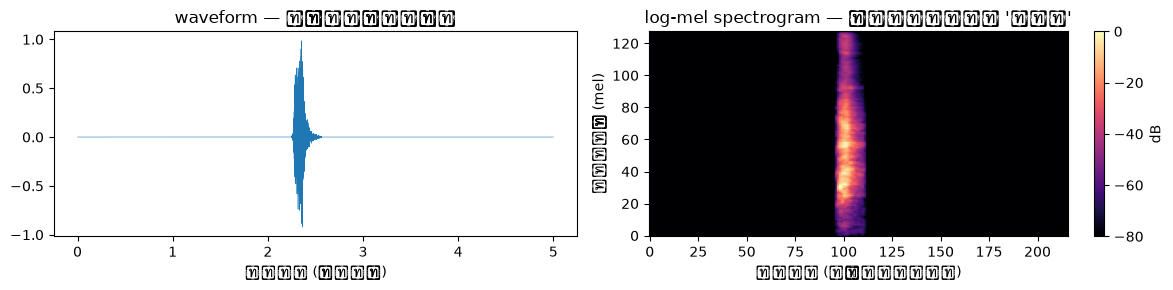

In [5]:
import librosa  # noqa: E402
import matplotlib.pyplot as plt  # noqa: E402
from IPython.display import Audio, display  # noqa: E402

SR = 22050
EXAMPLE = "1-100032-A-0.wav"  # เสียงหมาเห่า (class: dog)
y, _ = librosa.load(ESC50 / "audio" / EXAMPLE, sr=SR, mono=True)
print(f"{EXAMPLE} — {len(y) / SR:.1f} วินาที @ {SR} Hz "
      f"= {len(y):,} ตัวเลขดิบต่อคลิป")
display(Audio(data=y, rate=SR))

mel = librosa.power_to_db(
    librosa.feature.melspectrogram(y=y, sr=SR, n_mels=128),
    ref=np.max,
)
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(np.arange(len(y)) / SR, y, lw=0.4)
axes[0].set_title("waveform — คลื่นเสียงดิบ")
axes[0].set_xlabel("เวลา (วินาที)")
img = axes[1].imshow(mel, aspect="auto", origin="lower", cmap="magma")
axes[1].set_title("log-mel spectrogram — มุมมองแบบ 'ภาพ'")
axes[1].set_xlabel("เวลา (หน่วยเฟรม)")
axes[1].set_ylabel("ความถี่ (mel)")
fig.colorbar(img, ax=axes[1], label="dB")
plt.tight_layout()
plt.show()


**อ่านสองภาพ:** waveform บอกว่า "เสียงดังเมื่อไร" แต่มองไม่เห็นความถี่ —
spectrogram บอกทั้งความถี่และเวลาพร้อมกัน (แถบแนวนอน = เสียงโน้ตยาว, จุดแนวตั้ง =
เสียงกระแทกสั้น) โจทย์ของโมดูลนี้: **จากสิ่งที่มองเห็นใน spectrogram นี้
จะบีบลงเป็นตัวเลขไม่กี่ตัวที่ random forest กินได้ได้อย่างไร**

## 2. เสียง → ตัวเลข (1): MFCC

MFCC ทำงานประมาณนี้ต่อเฟรมสั้น ๆ (~23 ms):
1. FFT → รู้ว่าความถี่ไหนดังแค่ไหนในเฟรมนั้น
2. พับความถี่ด้วยตัวกรอง **mel** ~26 แถบ (ตามการได้ยินของหูมนุษย์)
3. คำนวณ log ของพลังงานแต่ละแถบ (หูไวกับ "สัดส่วน" มากกว่า "ผลต่าง")
4. **DCT** บีบ log-พลังงาน 26 ค่าให้เหลือสัมประสิทธิ์สำคัญ ~20 ตัวแรก

ผลลัพธ์ต่อคลิป 5 วินาที: ตารางเล็ก ๆ **20 × 216** (20 สัมประสิทธิ์ × 216 เฟรม) —
จาก 110,250 ตัวเลขดิบเหลือ ~4,300 ตัวเลขที่ "ฟัง" อยู่ในนั้น

/tmp/ipykernel_31132/722524422.py:9: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31132/722524422.py:9: UserWarning: Glyph 3615 (\N{THAI CHARACTER FO FAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31132/722524422.py:9: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31132/722524422.py:9: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31132/722524422.py:9: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31132/722524422.py:9: UserWarning: Glyph 3621 (\N{THAI CHARACTER LO LING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31132/722524422.py:9: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  plt.tight

MFCC: (20, 216) → 20 แถว × 216 เฟรม (~46 เฟรม/วินาที)


/Users/utarn/projects/ml-metrology/.claude/worktrees/issue-29/.check-env/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3586 (\N{THAI CHARACTER KHO KHAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.claude/worktrees/issue-29/.check-env/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.claude/worktrees/issue-29/.check-env/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3632 (\N{THAI CHARACTER SARA A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.claude/worktrees/issue-29/.check-env/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3597 (\N{THAI CHARACTER YO YING}) missing from font(s) Deja

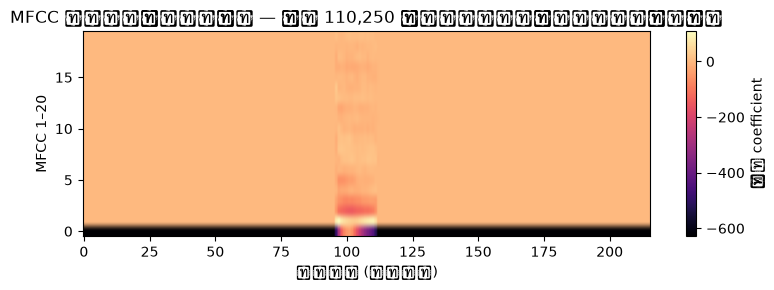

In [6]:
mfcc = librosa.feature.mfcc(y=y, sr=SR, n_mfcc=20)
print("MFCC:", mfcc.shape, "→ 20 แถว × 216 เฟรม (~46 เฟรม/วินาที)")
fig, ax = plt.subplots(figsize=(8, 3))
img = ax.imshow(mfcc, aspect="auto", origin="lower", cmap="magma")
fig.colorbar(img, ax=ax, label="ค่า coefficient")
ax.set_xlabel("เฟรม (เวลา)")
ax.set_ylabel("MFCC 1–20")
ax.set_title("MFCC ของเสียงเดิม — บีบ 110,250 ตัวเลขเหลือสาระสำคัญ")
plt.tight_layout()
plt.show()

## 3. เสียง → ตัวเลข (2): จากคลิปเดียวสู่ตาราง 2,000 แถว

MFCC 20 × 216 ยังเป็น "รูป" อยู่ — random forest กินได้เฉพาะ **แถวตาราง** ที่ยาวเท่ากัน
วิธีคลาสสิก: สรุปแต่ละ coefficient ด้วย **mean และ std ตลอดเวลา** → 20 × 2 =
**40 ตัวเลขต่อคลิป** (mean = "ลักษณะเสียงโดยรวม", std = "ความเปลี่ยนแปลงตามเวลา")

แล้วโจทย์ก็กลายเป็นตารางธรรมดา — งานเดิมที่คุณทำคล่องในคอร์ส DS:
**ตาราง 2,000 แถว × 40 คอลัมน์ + label 50 class → random forest**

In [7]:
from joblib import Parallel, delayed  # noqa: E402


def mfcc_row(path: Path) -> np.ndarray:
    """คลิปเดียว → เวกเตอร์ 40 ตัวเลข (mean+std ของ MFCC 20 ตัว)."""
    y, _ = librosa.load(path, sr=SR, mono=True)
    m = librosa.feature.mfcc(y=y, sr=SR, n_mfcc=20)
    return np.concatenate([m.mean(axis=1), m.std(axis=1)])


X = np.asarray(Parallel(n_jobs=-1)(
    delayed(mfcc_row)(p) for p in paths
))
print("X:", X.shape, "→ ตาราง 2,000 แถว × 40 feature")
print("ตัวอย่างแถวแรก (class =", id2cat[y_all[0]], "):")
print(np.round(X[0][:10], 2))

X: (2000, 40) → ตาราง 2,000 แถว × 40 feature
ตัวอย่างแถวแรก (class = dog ):
[-6.0094e+02  4.6900e+00 -8.5100e+00 -4.2800e+00 -8.2000e-01 -1.9700e+00
 -2.9000e-01  8.3000e-01  8.2000e-01  4.4000e-01]


## 4. เทรน random forest ด้วย 5-fold protocol ทางการของ ESC-50

**จุดที่ต้องระวังเป็นพิเศษ — data leakage:** ESC-50 ตัดคลิปมาจากไฟล์อัดยาว ๆ
คลิปหลายคลิปจึงมาจากไฟล์ต้นทางเดียวกัน (`src_file`) — ถ้าคลิปพี่น้องจากไฟล์เดียวกัน
ไปอยู่ทั้ง train ทั้ง test โมเดลจะ "จำเสียงห้องอัด/ไมโครโฟน" แล้วทำคะแนนฟุ่งเฟ้อ
ชุดข้อมูลจึง **จัด fold มาให้แล้ว** ให้คลิปญาติพี่น้องอยู่ fold เดียวกัน — เราแค่ใช้ให้ถูก

(งานเมโทรโลยีเจอเหมือนกัน: ข้อมูลจากเครื่อง/วันวัดเดียวกันต้องไม่กระจายข้าม
train-test ไม่งั้นโมเดลจำ "เครื่อง" แทนที่จะจำ "สภาพชิ้นงาน")

protocol ทางการ: วน 5 รอบ — แต่ละรอบเทรนด้วย 4 folds ทดสอบด้วยอีก fold หนึ่ง

In [8]:
from sklearn.ensemble import RandomForestClassifier  # noqa: E402
from sklearn.metrics import accuracy_score  # noqa: E402

accs = {}
for k in range(1, 6):
    tr, te = folds != k, folds == k
    rf = RandomForestClassifier(
        n_estimators=200, n_jobs=-1, random_state=SEED
    )
    rf.fit(X[tr], y_all[tr])
    accs[k] = accuracy_score(y_all[te], rf.predict(X[te]))
    print(f"fold {k}: accuracy = {accs[k]:.4f}")
acc_rf = float(np.mean(list(accs.values())))
print(f"mean accuracy (5 folds) = {acc_rf:.4f}")

fold 1: accuracy = 0.4350


fold 2: accuracy = 0.4375


fold 3: accuracy = 0.4600


fold 4: accuracy = 0.4725


fold 5: accuracy = 0.4675
mean accuracy (5 folds) = 0.4545


**อ่านผล:** accuracy ราว **0.45** — สูงกว่าการเดาสุ่ม (1/50 = 0.02) มหาศาล
และใกล้เคียง baseline ที่เผยแพร่ไว้ของชุดข้อมูลนี้ (**RF + MFCC & ZCR = 44.3%**
จาก paper ต้นฉบับของ Piczak) — เสียงสิ่งแวดล้อม 50 class จำแนกด้วย feature แบบ
สรุปค่าทางสถิติ 40 ตัวเลขได้แค่นี้จริง ข้อจำกัดอยู่ที่ **feature** ไม่ใช่ตัวโมเดล

### 4.1 โมเดลพลาดอะไร — confusion matrix ของ fold 5

/tmp/ipykernel_31132/3524742409.py:13: UserWarning: Glyph 3610 (\N{THAI CHARACTER BO BAIMAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31132/3524742409.py:13: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31132/3524742409.py:13: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31132/3524742409.py:13: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31132/3524742409.py:13: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31132/3524742409.py:13: UserWarning: Glyph 3621 (\N{THAI CHARACTER LO LING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31132/3524742409.py:13: UserWarning: Glyph 3586 (\N{THAI CHARACTER KHO KHAI}) missing from font(s) DejaVu

/Users/utarn/projects/ml-metrology/.claude/worktrees/issue-29/.check-env/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3610 (\N{THAI CHARACTER BO BAIMAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.claude/worktrees/issue-29/.check-env/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.claude/worktrees/issue-29/.check-env/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.claude/worktrees/issue-29/.check-env/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) Deja

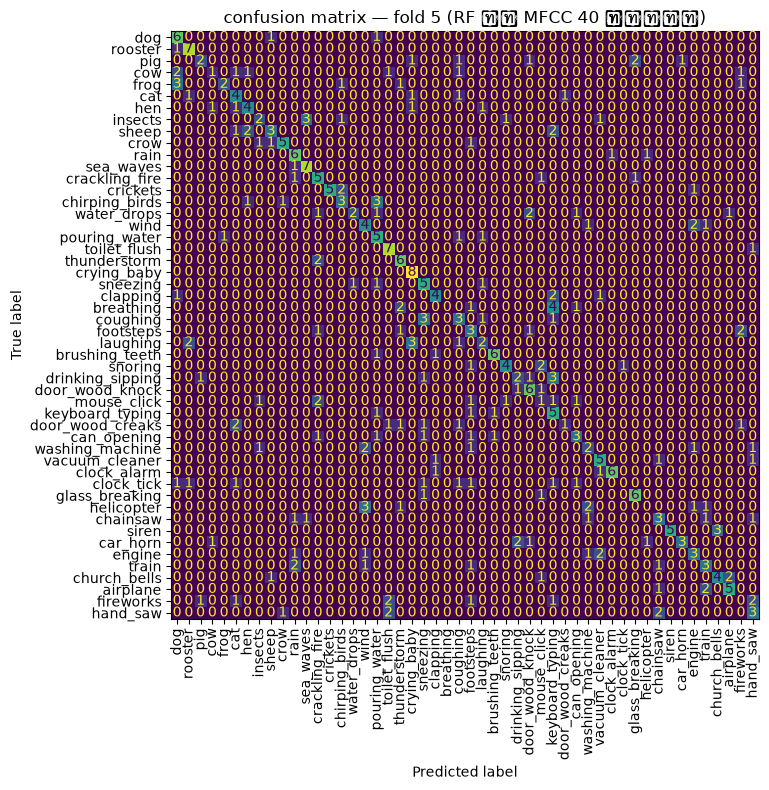

คู่สับสนบ่อยสุด (จริง → ทำนายผิด):
  breathing → keyboard_typing: 4 ครั้ง
  siren → church_bells: 3 ครั้ง
  frog → dog: 3 ครั้ง
  helicopter → wind: 3 ครั้ง
  insects → sea_waves: 3 ครั้ง
  drinking_sipping → keyboard_typing: 3 ครั้ง
  coughing → sneezing: 3 ครั้ง
  laughing → crying_baby: 3 ครั้ง


In [9]:
import matplotlib.pyplot as plt  # noqa: E402
from collections import Counter  # noqa: E402
from sklearn.metrics import ConfusionMatrixDisplay  # noqa: E402

te5 = folds == 5
pred5 = rf.predict(X[te5])
fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay.from_predictions(
    y_all[te5], pred5, ax=ax, colorbar=False,
    display_labels=id2cat, xticks_rotation=90,
)
ax.set_title("confusion matrix — fold 5 (RF บน MFCC 40 ตัวเลข)")
plt.tight_layout()
plt.show()

wrong = Counter(
    (id2cat[t], id2cat[p])
    for t, p in zip(y_all[te5], pred5) if t != p
)
print("คู่สับสนบ่อยสุด (จริง → ทำนายผิด):")
for (t, p), n in wrong.most_common(8):
    print(f"  {t} → {p}: {n} ครั้ง")

**อ่าน confusion:** คู่ที่สับสนเป็นเสียงที่ "ใกล้กัน" ตามหูมนุษย์ด้วย —
เสียงหายใจ/เสียงคนกับเสียงคลิกคีย์บอร์ด (จังหวะสั้น ๆ ซ้ำ ๆ), เสียงไซเรนกับ
ระฆังโบสถ์ (โทนต่อเนื่องยาว), เสียงกบกับเสียงหมา (เสียงร้องสัตว์) — MFCC สรุป
เป็น mean/std ต่อ coefficient แล้วสองเสียงแบบนี้มีตัวเลขใกล้กันจริง

## 5. เทียบกับ spectrogram CNN — ครึ่งหลังของโมดูล

โมดูล M4-CNN (`day2/module4_esc50_cnn/` บน Kaggle GPU) เอา **log-mel spectrogram
เต็ม 128 × 216** (ไม่บีบเป็น 40 ตัวเลข) ป้อนเข้า CNN ให้โมเดลเรียนรู้ pattern เอง
— เหมือน M1 ที่ CNN ชนะ HOG+SVM เพราะไม่ต้องเสียข้อมูลตรงการบีบ feature ด้วยมือ

| วิธี | input ต่อคลิป | ที่รัน | accuracy |
|---|---|---|---|
| **RF บน MFCC** (โมดูลนี้) | ตาราง 40 ตัวเลข (mean+std) | CPU เครื่องนี้ — วินาที | ด้านบน (5-fold mean ~0.45) |
| **CNN จากศูนย์ บน log-mel** | ภาพ 128 × 216 ค่า dB | Kaggle T4 — ~15–25 นาที | คาดหมาย ~0.60–0.75 — ดูค่าจริงจากโน้ตบุ๊ก CNN |
| *อ้างอิง paper: RF baseline* | MFCC + ZCR | — | *0.4430* (5-fold mean) |
| *อ้างอิง paper: CNN baseline* | mel-spectrogram | — | *0.6450* (5-fold mean) |
| *อ้างอิง: คนจริงตัดสินใจ* | หู | — | *0.8130* |

(ตัวเลขอ้างอิงจากตาราง results ใน [repo ของ ESC-50](https://github.com/karoldvl/ESC-50)
— โมเดล pretrained ยุคใหม่ทำได้ถึง 95%+ แต่นอกขอบเขตโมดูลนี้)

In [10]:
summary = pd.DataFrame({
    "วิธี": [
        "RF บน MFCC (โมดูลนี้)",
        "CNN จากศูนย์ บน log-mel",
    ],
    "input ต่อคลิป": [
        "ตาราง 40 ตัวเลข (mean+std)",
        "ภาพ 128x216 ค่า dB",
    ],
    "ที่รัน": [
        "เครื่องนี้ (CPU, offline)",
        "Kaggle T4 — day2/module4_esc50_cnn/",
    ],
    "accuracy": [
        f"5-fold mean = {acc_rf:.4f} "
        f"(fold 5 = {accs[5]:.4f})",
        "คาดหมาย ~0.60-0.75 — ดูค่าจริงจากโน้ตบุ๊ก CNN",
    ],
})
print(summary.to_string(index=False))


                   วิธี              input ต่อคลิป                              ที่รัน                                      accuracy
  RF บน MFCC (โมดูลนี้) ตาราง 40 ตัวเลข (mean+std)           เครื่องนี้ (CPU, offline)        5-fold mean = 0.4545 (fold 5 = 0.4675)
CNN จากศูนย์ บน log-mel         ภาพ 128x216 ค่า dB Kaggle T4 — day2/module4_esc50_cnn/ คาดหมาย ~0.60-0.75 — ดูค่าจริงจากโน้ตบุ๊ก CNN


### Trade-off ที่ต้องจำ (สรุปของโมดูล)

- **RF + MFCC (สะพานจาก DS):** เร็ว, รันบน CPU ธรรมดา, อธิบายได้ (ดู
  feature importance ได้), ใช้ทักษะเดิมทั้งหมด — แต่เพดาน accuracy ต่ำกว่า เพราะ
  การบีบ 110,250 ตัวเลข → 40 ตัวเลข ตัดข้อมูล texture ละเอียดทิ้งไปตามสมมติฐาน
  ของคนที่ออกแบบ feature
- **CNN + spectrogram:** accuracy สูงกว่าชัดเจน เพราะอ่านข้อมูลดิบของ spectrogram
  ทั้งหมดและเรียนรู้ feature เอง — แต่ต้องใช้ GPU, เทรนนานกว่าเท่าตัว, อธิบายยาก
- **ทางเลือกที่ดีที่สุดสำหรับงานจริง:** เริ่มจาก feature + RF เสมอ (ได้ baseline
  ถูกและไว) แล้วตัดสินว่า accuracy ที่เพิ่มได้จาก CNN คุ้มกับต้นทุน GPU/ความซับซ้อน
  ไหม — หลักคิดเดียวกับ M1

**และอย่าลืม:** ข้อมูล ESC-50 เป็น **CC BY-NC 3.0** — ผลงานที่เทรนจากชุดนี้ใช้
เชิงพาณิชย์/แจกต่อนอกห้องเรียนไม่ได้ ถ้าโจทย์จริงของทีมต้องแจกต่อ ให้สลับไป
Speech Commands v2 (CC BY 4.0)

## สรุป

เสียงไม่ใช่ตาราง — แต่พอเลือก feature ให้ฉลาด (MFCC: สเกล mel + DCT) เสียง 5
วินาทีก็กลายเป็นแถว 40 ตัวเลขที่ random forest ของคอร์ส DS กินได้ทันที ได้
accuracy ~0.45 บน 50 class ตรง baseline ของ paper — ครึ่งหลังของโมดูลจะพาไป
ดูว่าถ้ายกข้อจำกัด "บีบเอง" ออกด้วย spectrogram + CNN บน Kaggle GPU จะได้เพิ่มกี่เปอร์เซ็นต์

**ต่อใน:** `day2/module4_esc50_cnn/book.ipynb` (Kaggle GPU) · ลองเองใน
`exercise.ipynb` · เฉลยใน `solution.ipynb`